In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Manga vs. Anime: Part 2
* What makes them good vs. popular?

In [2]:
manga_data = pd.read_csv("manga.csv")

In [3]:
anime_data = pd.read_csv("anime.csv")

In [4]:
manga_data.shape

(64833, 30)

In [5]:
anime_data.shape

(24985, 39)

In [6]:
set(manga_data.columns) - set(anime_data.columns)

{'authors',
 'chapters',
 'created_at_before',
 'manga_id',
 'serializations',
 'volumes'}

In [7]:
set(anime_data.columns) - set(manga_data.columns)

{'anime_id',
 'broadcast_day',
 'broadcast_time',
 'created_at',
 'episode_duration',
 'episodes',
 'licensors',
 'producers',
 'rating',
 'source',
 'start_season',
 'start_year',
 'studios',
 'total_duration',
 'trailer_url'}

In [8]:
set(anime_data.columns) & set(manga_data.columns)

{'approved',
 'background',
 'demographics',
 'end_date',
 'favorites',
 'genres',
 'main_picture',
 'members',
 'real_end_date',
 'real_start_date',
 'score',
 'scored_by',
 'sfw',
 'start_date',
 'status',
 'synopsis',
 'themes',
 'title',
 'title_english',
 'title_japanese',
 'title_synonyms',
 'type',
 'updated_at',
 'url'}

In [9]:
anime_data.title.sample(20)

19678                            Watashi no Kamifuusen
21310                                Baoxiao Haha Zhen
10396                                    Legend of Duo
13032                                      Hane (2015)
23032                                      Heper Yijia
1133           Itsudatte Bokura no Koi wa 10 cm Datta.
23800                                       Tube Angel
2297                                Petshop of Horrors
21252                                           Dennou
11579                                    Kizuna (2014)
13208                                   Kemeko no Love
21093                                   Iyagi Yeohaeng
17203                                     Bite-Choicar
13744                                     Kamo ga Suki
11518                            1000-mankai Hug Nanda
17825    Shining Star: Saeroun Luna-Queen-ui Tansaeng!
4692                                Rockman.EXE Stream
24664                             Huan Yue Da Lianmeng
21894     

(array([5.614e+03, 9.705e+03, 5.787e+03, 2.259e+03, 1.060e+03, 3.610e+02,
        1.330e+02, 4.900e+01, 1.100e+01, 6.000e+00]),
 array([  1. ,  13.5,  26. ,  38.5,  51. ,  63.5,  76. ,  88.5, 101. ,
        113.5, 126. ]),
 <BarContainer object of 10 artists>)

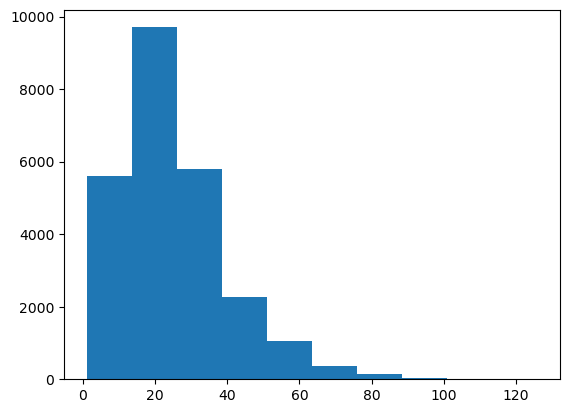

In [10]:
plt.hist(anime_data.title.str.len())

(array([2.700e+01, 7.100e+01, 1.730e+02, 2.620e+02, 8.490e+02, 5.340e+02,
        5.760e+02, 6.690e+02, 1.514e+03, 9.390e+02, 9.850e+02, 9.980e+02,
        9.900e+02, 1.865e+03, 8.060e+02, 7.320e+02, 7.090e+02, 1.347e+03,
        6.710e+02, 6.020e+02, 5.600e+02, 6.010e+02, 1.061e+03, 5.320e+02,
        4.640e+02, 4.520e+02, 7.810e+02, 4.050e+02, 3.160e+02, 3.500e+02,
        2.650e+02, 4.950e+02, 2.280e+02, 2.070e+02, 2.070e+02, 3.750e+02,
        1.690e+02, 1.460e+02, 1.520e+02, 2.800e+02, 1.270e+02, 8.900e+01,
        1.040e+02, 1.000e+02, 1.830e+02, 6.700e+01, 8.300e+01, 6.000e+01,
        1.430e+02, 6.000e+01, 4.400e+01, 3.800e+01, 6.000e+01, 6.600e+01,
        4.000e+01, 2.600e+01, 2.100e+01, 4.800e+01, 1.500e+01, 2.300e+01,
        2.400e+01, 1.600e+01, 2.000e+01, 1.400e+01, 1.600e+01, 9.000e+00,
        2.000e+01, 1.100e+01, 6.000e+00, 1.000e+01, 1.100e+01, 8.000e+00,
        9.000e+00, 3.000e+00, 4.000e+00, 7.000e+00, 6.000e+00, 3.000e+00,
        3.000e+00, 4.000e+00, 2.000e+0

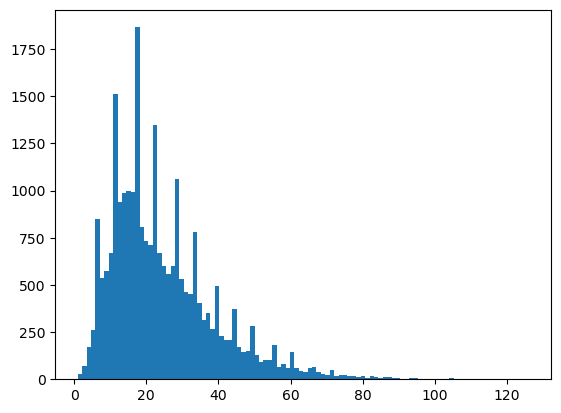

In [11]:
plt.hist(anime_data.title.str.len(), bins = "fd")

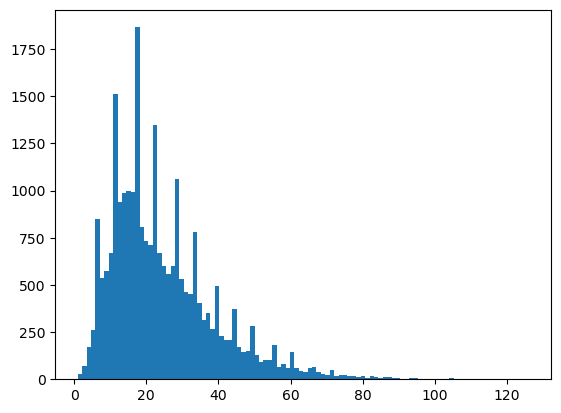

In [12]:
plt.hist(anime_data.title.str.len(), bins = "fd")
plt.show()

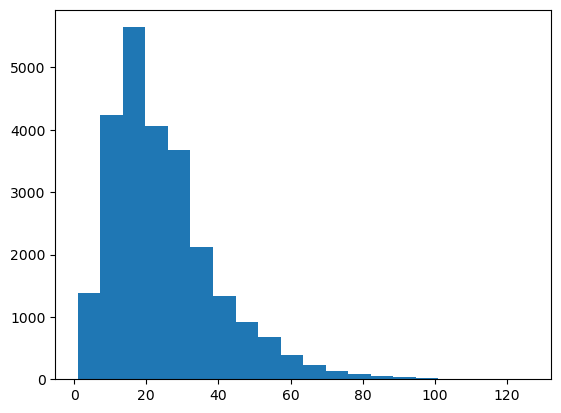

In [13]:
plt.hist(anime_data.title.str.len(), bins = 20)
plt.show()

In [14]:
anime_data.title_japanese

0        鋼の錬金術師 FULLMETAL ALCHEMIST
1          HUNTER×HUNTER（ハンター×ハンター）
2              進撃の巨人 Season3 Part.2
3                       STEINS;GATE
4                               聲の形
                    ...            
24980                           精造機
24981                           感謝状
24982                  かいじゅうせかいせいふく
24983                     四つ角のメロディー
24984                           飴と鎖
Name: title_japanese, Length: 24985, dtype: object

In [15]:
len(anime_data.title_synonyms)

24985

In [16]:
anime_data.title_synonyms.apply(lambda x: len(x))

0        94
1        14
2         2
3         2
4        22
         ..
24980     2
24981    16
24982     2
24983    16
24984    20
Name: title_synonyms, Length: 24985, dtype: int64

In [17]:
indices = anime_data.title_synonyms.apply(lambda x: len(x))[anime_data.title_synonyms.apply(lambda x: len(x)) > 2].nlargest(20).index#.sample(20, random_state=123).index 

In [18]:
anime_data.loc[indices].title_synonyms.values

array(["['Opening Ceremony', 'Hellmarathon Women', 'Brancer', 'Baka Modern Tetrathlon', 'Homeathlon', 'Watakkyu', 'Doping Freestyle', 'Locker Room', 'Independence Men', 'Ironball Throwing Men', 'Samurai Call', 'Humanism Men', 'Giant Sumo', 'The Race for Love', 'Animal Lifting', '1000 Characters SMSing']",
       "['Curious Fruit', 'Kimyou na Kajitsu', 'Sacred Girl', 'Sei Shoujo', 'Lover Doll', 'Aigan Shoujo', 'Kirei', 'KI・RE・I', 'Kotoyoshi Yumisuke Mirei', 'Seek', 'Yellow Star', 'Slaver Warrior Maya', 'Dorei Senshi Maya', 'Binding', 'Kousoku', 'Fallen Angel Rina', 'Idol Datenshi Rina']",
       "['Animation! Tomoyoshi Joko & Hiroco Ichinose Film Works 2009', 'Mr. Cloud and Mr. Rain', 'Buildings', 'Lizard Planet', 'Kanagawa Dog', 'annihilation', 'The last breakfast', 'Ushi Nichi', 'ha-P', 'COSMIC! (pilot film)', 'YOKOHA-MAMAN', 'morning (pilot film)', 'Buil-Bun']",
       "['Pink Lady 34', 'Pink Lady 35', 'Pink Lady Monogatari: Eikou no Tenshi-tachi Recaps', 'Pink Lady Monogatari: Eikou

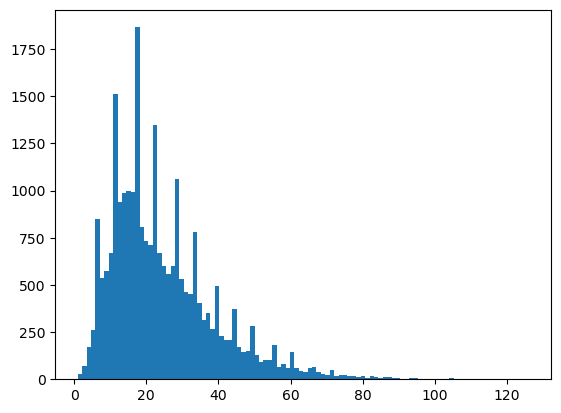

In [19]:
bins = plt.hist(anime_data.title.str.len(), bins = "fd")

In [20]:
bins


(array([2.700e+01, 7.100e+01, 1.730e+02, 2.620e+02, 8.490e+02, 5.340e+02,
        5.760e+02, 6.690e+02, 1.514e+03, 9.390e+02, 9.850e+02, 9.980e+02,
        9.900e+02, 1.865e+03, 8.060e+02, 7.320e+02, 7.090e+02, 1.347e+03,
        6.710e+02, 6.020e+02, 5.600e+02, 6.010e+02, 1.061e+03, 5.320e+02,
        4.640e+02, 4.520e+02, 7.810e+02, 4.050e+02, 3.160e+02, 3.500e+02,
        2.650e+02, 4.950e+02, 2.280e+02, 2.070e+02, 2.070e+02, 3.750e+02,
        1.690e+02, 1.460e+02, 1.520e+02, 2.800e+02, 1.270e+02, 8.900e+01,
        1.040e+02, 1.000e+02, 1.830e+02, 6.700e+01, 8.300e+01, 6.000e+01,
        1.430e+02, 6.000e+01, 4.400e+01, 3.800e+01, 6.000e+01, 6.600e+01,
        4.000e+01, 2.600e+01, 2.100e+01, 4.800e+01, 1.500e+01, 2.300e+01,
        2.400e+01, 1.600e+01, 2.000e+01, 1.400e+01, 1.600e+01, 9.000e+00,
        2.000e+01, 1.100e+01, 6.000e+00, 1.000e+01, 1.100e+01, 8.000e+00,
        9.000e+00, 3.000e+00, 4.000e+00, 7.000e+00, 6.000e+00, 3.000e+00,
        3.000e+00, 4.000e+00, 2.000e+0

In [21]:
len(bins[0])

102

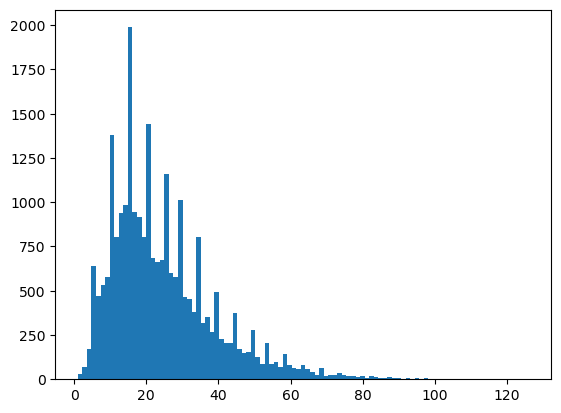

In [22]:
bins = plt.hist(anime_data.title.str.len(), bins = 99)


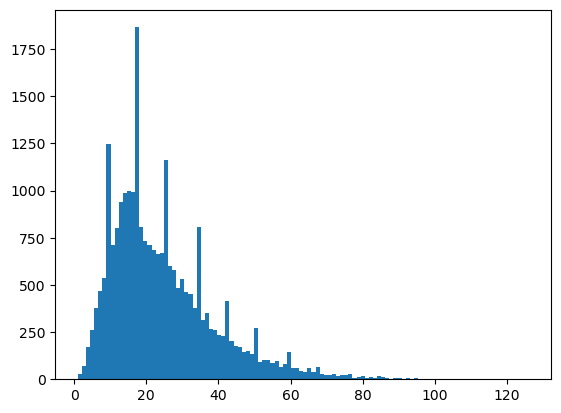

In [23]:
bins = plt.hist(anime_data.title.str.len(), bins = 110)

In [24]:
bins[0]

array([2.700e+01, 7.100e+01, 1.730e+02, 2.620e+02, 3.790e+02, 4.700e+02,
       5.340e+02, 1.245e+03, 7.130e+02, 8.010e+02, 9.390e+02, 9.850e+02,
       9.980e+02, 9.900e+02, 1.865e+03, 8.060e+02, 7.320e+02, 7.090e+02,
       6.830e+02, 6.640e+02, 6.710e+02, 1.162e+03, 6.010e+02, 5.800e+02,
       4.810e+02, 5.320e+02, 4.640e+02, 4.520e+02, 3.800e+02, 8.060e+02,
       3.160e+02, 3.500e+02, 2.650e+02, 2.590e+02, 2.360e+02, 2.280e+02,
       4.140e+02, 2.010e+02, 1.740e+02, 1.690e+02, 1.460e+02, 1.520e+02,
       1.340e+02, 2.730e+02, 8.900e+01, 1.040e+02, 1.000e+02, 8.800e+01,
       9.500e+01, 6.700e+01, 8.300e+01, 1.420e+02, 6.100e+01, 6.000e+01,
       4.400e+01, 3.800e+01, 6.000e+01, 4.000e+01, 6.600e+01, 2.600e+01,
       2.100e+01, 2.200e+01, 2.600e+01, 1.500e+01, 2.300e+01, 2.400e+01,
       2.700e+01, 9.000e+00, 1.400e+01, 1.600e+01, 9.000e+00, 1.200e+01,
       8.000e+00, 1.700e+01, 1.000e+01, 8.000e+00, 3.000e+00, 8.000e+00,
       9.000e+00, 3.000e+00, 7.000e+00, 4.000e+00, 

In [25]:
list(zip(bins[0],bins[1]))

[(np.float64(27.0), np.float64(1.0)),
 (np.float64(71.0), np.float64(2.1363636363636367)),
 (np.float64(173.0), np.float64(3.272727272727273)),
 (np.float64(262.0), np.float64(4.409090909090909)),
 (np.float64(379.0), np.float64(5.545454545454546)),
 (np.float64(470.0), np.float64(6.6818181818181825)),
 (np.float64(534.0), np.float64(7.818181818181818)),
 (np.float64(1245.0), np.float64(8.954545454545455)),
 (np.float64(713.0), np.float64(10.090909090909092)),
 (np.float64(801.0), np.float64(11.227272727272728)),
 (np.float64(939.0), np.float64(12.363636363636365)),
 (np.float64(985.0), np.float64(13.500000000000002)),
 (np.float64(998.0), np.float64(14.636363636363637)),
 (np.float64(990.0), np.float64(15.772727272727273)),
 (np.float64(1865.0), np.float64(16.90909090909091)),
 (np.float64(806.0), np.float64(18.045454545454547)),
 (np.float64(732.0), np.float64(19.181818181818183)),
 (np.float64(709.0), np.float64(20.31818181818182)),
 (np.float64(683.0), np.float64(21.454545454545457

In [26]:
title_lengths = anime_data.title.str.len()
title_lengths

0        32
1        22
2        34
3        11
4        14
         ..
24980     7
24981     9
24982    20
24983    19
24984    13
Name: title, Length: 24985, dtype: int64

In [27]:
current_title_length = title_lengths[(title_lengths >= 10) & (title_lengths <= 30)]

(array([ 669.,  713.,  801.,  939.,  985.,  998.,  990.,  946.,  919.,
         806.,  732.,  709.,  683.,  664.,  671.,  602.,  560.,  601.,
         580., 1013.]),
 array([10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22.,
        23., 24., 25., 26., 27., 28., 29., 30.]),
 <BarContainer object of 20 artists>)

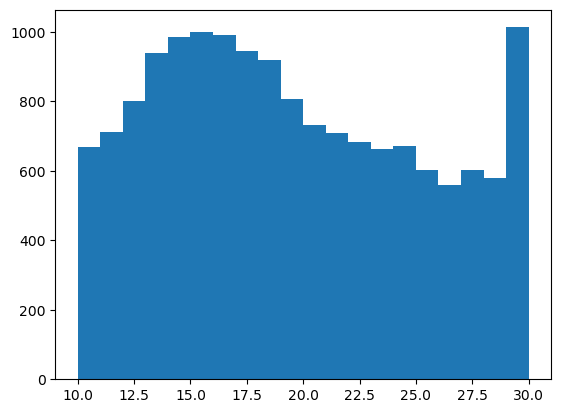

In [28]:
plt.hist(current_title_length, bins = "fd")

In [29]:
current_title_length = title_lengths[(title_lengths == 30)]
anime_data.loc[current_title_length.index].title.sort_values().to_csv("len_30.csv")

In [30]:
anime_data[anime_data.title.str.contains(":", regex = False)].sort_values("title")[["title", "type", "episodes"]].to_csv("multipart_titles.csv")

In [31]:
6543 / len(anime_data)

0.2618771262757655

In [32]:
anime_data[anime_data.title.str.contains("season", case = False, regex = False)].sort_values("title")[["title", "type", "episodes"]].to_csv("titles_season.csv")

In [33]:
anime_data[anime_data.title.str.contains(":", regex = False)].title.str.split(":", expand = True)[0].value_counts()

0
Sore Ike! Anpanman                   75
Lupin III                            44
Shounen Sunday CM                    35
Code Geass                           33
Xi Yangyang Yu Hui Tailang           33
                                     ..
Narutaru                              1
Sister Princess                       1
Happy☆Lesson                          1
Yubisaki kara Honki no Netsujou 2     1
Jijia Yingxiong Movie                 1
Name: count, Length: 4023, dtype: int64

In [34]:
len(anime_data[anime_data.title.str.contains(":", regex = False)])

6543

In [35]:
title_lengths = manga_data.title.str.len()

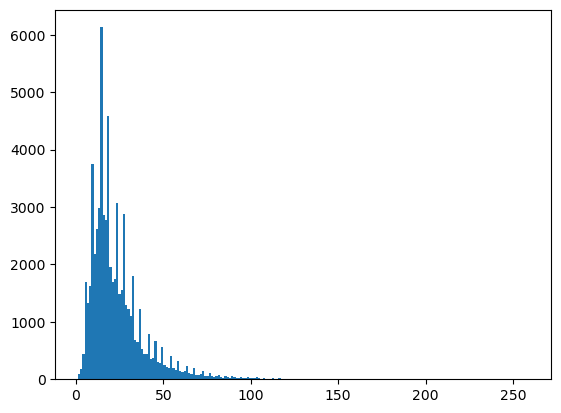

In [36]:
plt.hist(title_lengths,bins = 200)
plt.show()

In [37]:
long_titles = title_lengths[title_lengths >= 150]

In [38]:
long_title_items = manga_data.loc[long_titles.index]

In [39]:
long_title_items.title.to_csv("long_manga_titles.csv")

In [40]:
title_lengths = manga_data.title_english.str.len()

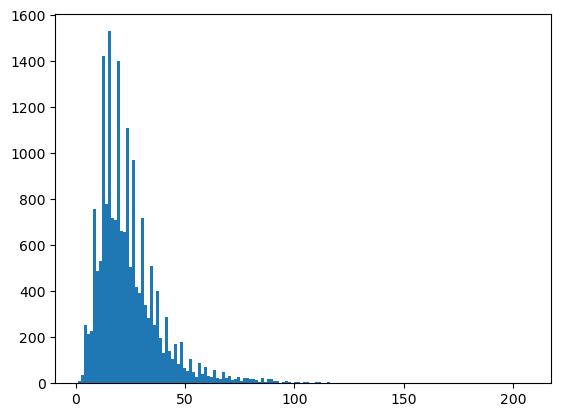

In [41]:
plt.hist(title_lengths, bins = 150)
plt.show()

In [42]:
long_titles = title_lengths[title_lengths >= 80]
long_title_items = manga_data.loc[long_titles.index]
len(long_title_items)
# long_title_items.title.sort_values().to_csv("long_manga_titles_en.csv")

228

In [43]:
pd.qcut(title_lengths, 20).value_counts().sort_index()

title_english
(0.999, 8.0]     1078
(8.0, 10.0]       905
(10.0, 12.0]     1190
(12.0, 13.0]      764
(13.0, 14.0]      778
(14.0, 16.0]     1531
(16.0, 17.0]      718
(17.0, 18.0]      711
(18.0, 20.0]     1401
(20.0, 21.0]      661
(21.0, 22.0]      658
(22.0, 24.0]     1109
(24.0, 26.0]     1012
(26.0, 28.0]      888
(28.0, 30.0]      780
(30.0, 33.0]      953
(33.0, 37.0]      961
(37.0, 42.0]      824
(42.0, 53.0]      903
(53.0, 207.0]     891
Name: count, dtype: int64

In [44]:
manga_data.loc[title_lengths[title_lengths > 53].index].to_csv("long_manga_titles_top_5.csv")

In [45]:
title_lengths.skew()

np.float64(2.2087685919237834)

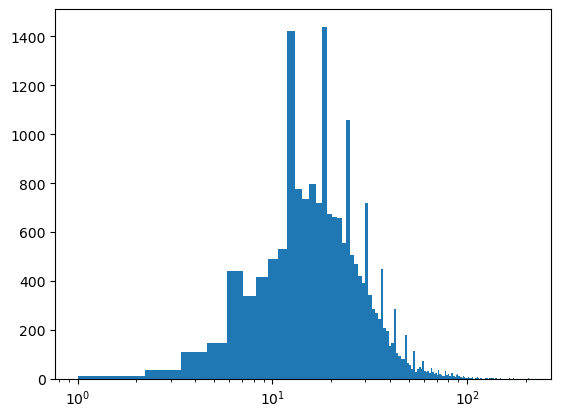

In [46]:
plt.hist(title_lengths, bins = "fd")
plt.semilogx()
plt.show()

In [47]:
title_lengths.mean()

np.float64(24.44459286172259)

In [48]:
title_lengths.std()

15.199890923715278

In [49]:
len(title_lengths[(title_lengths > (24-15)) & (title_lengths < (24 + 15))] / len(title_lengths)

_IncompleteInputError: incomplete input (1337798491.py, line 1)

In [50]:
lower_bound = title_lengths.mean() - 2 * title_lengths.std()
upper_bound = title_lengths.mean() + 2 * title_lengths.std()
len(
    title_lengths[
        (title_lengths > lower_bound) &
        (title_lengths < upper_bound)
    ]
) / len(title_lengths)

0.27570835839772956

In [51]:
manga_data[manga_data.title.str.contains(":")]

,manga_id,title,type,score,scored_by,status,volumes,chapters,start_date,end_date,...,demographics,authors,serializations,synopsis,background,main_picture,url,title_english,title_japanese,title_synonyms
2,1706,JoJo no Kimyou na Bouken Part 7: Steel Ball Run,manga,9.30,151433,finished,24.0,96.0,2004-01-19,2011-04-19,...,"['Seinen', 'Shounen']","[{'id': 2619, 'first_name': 'Hirohiko', 'last_...",['Ultra Jump'],"In the American Old West, the world's greatest...",JoJo no Kimyou na Bouken Part 7: Steel Ball Ru...,https://cdn.myanimelist.net/images/manga/3/179...,https://myanimelist.net/manga/1706/JoJo_no_Kim...,NaN,ジョジョの奇妙な冒険 Part7 STEEL BALL RUN,"[""JoJo's Bizarre Adventure Part 7: Steel Ball ..."
7,90125,Kaguya-sama wa Kokurasetai: Tensai-tachi no Re...,manga,8.92,123341,finished,28.0,281.0,2015-05-19,2022-11-02,...,['Seinen'],"[{'id': 2139, 'first_name': 'Aka', 'last_name'...",['Young Jump'],Considered a genius due to having the highest ...,Kaguya-sama wa Kokurasetai: Tensai-tachi no Re...,https://cdn.myanimelist.net/images/manga/3/188...,https://myanimelist.net/manga/90125/Kaguya-sam...,Kaguya-sama: Love Is War,かぐや様は告らせたい～天才たちの恋愛頭脳戦～,"[""Kaguya Wants to be Confessed To: The Geniuse..."
39,3006,JoJo no Kimyou na Bouken Part 4: Diamond wa Ku...,manga,8.57,58809,finished,18.0,174.0,1992-04-21,1995-11-21,...,['Shounen'],"[{'id': 2619, 'first_name': 'Hirohiko', 'last_...",['Shounen Jump (Weekly)'],"In 1999, Joutarou Kuujou arrives at the Japane...",JoJo no Kimyou na Bouken Part 4: Diamond wa Ku...,https://cdn.myanimelist.net/images/manga/3/269...,https://myanimelist.net/manga/3006/JoJo_no_Kim...,JoJo's Bizarre Adventure Part 4: Diamond Is Un...,ジョジョの奇妙な冒険 ダイヤモンドは砕けない,"['Diamond Is Not Crash', 'Dai 4 Bu: Higashikat..."
47,22,Rurouni Kenshin: Meiji Kenkaku Romantan,manga,8.56,46255,finished,28.0,259.0,1994-04-12,1999-09-21,...,['Shounen'],"[{'id': 1890, 'first_name': 'Nobuhiro', 'last_...",['Shounen Jump (Weekly)'],Ten years have passed since the end of Bakumat...,Rurouni Kenshin: Meiji Kenkaku Romantan was pu...,https://cdn.myanimelist.net/images/manga/2/127...,https://myanimelist.net/manga/22/Rurouni_Kensh...,Rurouni Kenshin: Meiji Swordsman Romantic Story,るろうに剣心 -明治剣客浪漫譚-,"['Samurai X', 'Sengoku no Mikazuki', 'Crescent..."
49,25515,JoJo no Kimyou na Bouken Part 8: JoJolion,manga,8.48,64851,finished,27.0,110.0,2011-05-19,2021-08-19,...,['Seinen'],"[{'id': 2619, 'first_name': 'Hirohiko', 'last_...",['Ultra Jump'],"In 2011, childhood friends Yasuho Hirose and J...",JoJo no Kimyou na Bouken Part 8: JoJolion won ...,https://cdn.myanimelist.net/images/manga/1/179...,https://myanimelist.net/manga/25515/JoJo_no_Ki...,NaN,ジョジョの奇妙な冒険 Part8 ジョジョリオン,"['Jojorion', ""JoJo's Bizarre Adventure Part 8:..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64802,121023,Siren No.46: Takeuchi Tamon Kenkyuu Note,one_shot,NaN,1,finished,NaN,1.0,2016-10-27,2016-10-27,...,[],"[{'id': 66218, 'first_name': 'Tsutomu', 'last_...",['Garaku no Mori'],A side story to the original 2003 video game.,NaN,https://cdn.myanimelist.net/images/manga/3/283...,https://myanimelist.net/manga/121023/Siren_No4...,NaN,SIREN No.46竹内多聞研究ノート,"[""Siren No.046: Tamon Takeuchi's Research Notes""]"
64806,137025,"Maa Maa Maa, Chanto Maou wa Taoshimasu kara, I...",manga,NaN,0,finished,NaN,3.0,2021-05-28,2021-07-09,...,['Seinen'],"[{'id': 65827, 'first_name': 'Yasutaka', 'last...",['Big Comic Superior'],NaN,NaN,https://cdn.myanimelist.net/images/manga/1/282...,https://myanimelist.net/manga/137025/Maa_Maa_M...,"Well, Well, I'll Take Down the Devil King, So ...",まあまあまあ、ちゃんと魔王は倒しますから、一回だけ～非正規雇用の俺が勇者になったら不倫偏差値56～,[]
64809,139509,Shiritsu Isekai Youchien: Yuusha no Musume to ...,manga,NaN,0,finished,NaN,4.0,2020-08-21,2021-06-22,...,[],"[{'id': 19117, 'first_name': 'Akuro', 'last_na...",['Gangan Joker'],NaN,NaN,https://cdn.myanimelist.net/images/manga/2/281...,https://myanimelist.net/manga/139509/Shiritsu_...,NaN,私立異世界幼稚園 ～勇者の娘と魔王の娘の最終戦争〈ラグナロク〉阻止がお仕事です～,['

In [52]:
manga_data[manga_data.title.str.contains(":")].title.sort_values()

39326    "Chikatetsu ni Noru" Series: Kyo Girls Days - ...
37070    "Ecchi shitai" to Itte Kure: Seijin(?) Buchou ...
7704       "Fushigi" Toriatsukaimasu: Tsukumodou Kottouten
46361    "Hora, Ore no Ue ni Matagare yo": Gouman Joush...
56643    "Jimi de Tsumaranai" to Suterareta node, Jimic...
                               ...                        
29202                        α no Hanayome: Kyoumei Renjou
37966                 †Ankoku Datsui†: Kaichou to Kuro Gal
56431               √4: Uchi no Juunin wa Minna Ijou desu.
55739               ○×△ Base: Nettori Guchagucha Celluloid
8749                                ♭38℃: Loveberry Twins♥
Name: title, Length: 8590, dtype: object

In [53]:
8590 / len(manga_data)

0.13249425446917465

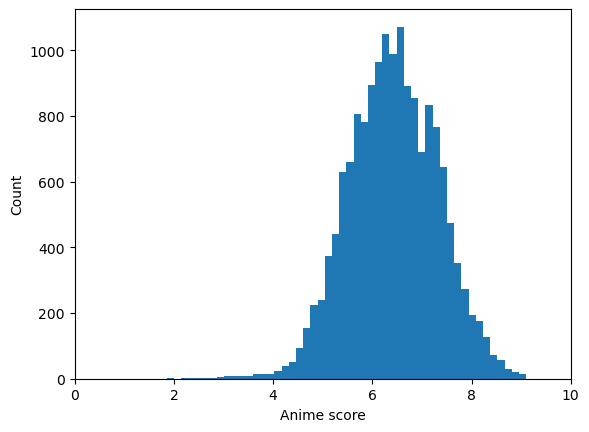

In [54]:
plt.hist(anime_data.score, bins = 50)
plt.xlabel("Anime score")
plt.ylabel("Count")
plt.xlim(0, 10)
plt.show()

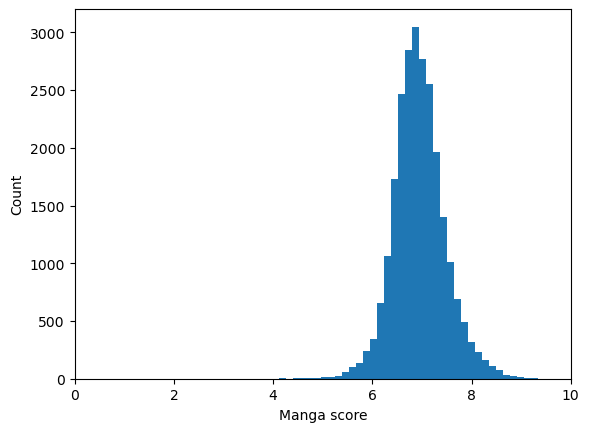

In [55]:
plt.hist(manga_data.score, bins = 50)
plt.xlabel("Manga score")
plt.ylabel("Count")
plt.xlim(0, 10)
plt.show()

In [56]:
anime_data.score.mean(), anime_data.score.std()

(np.float64(6.418469781931465), 0.8993046454214667)

In [57]:
manga_data.score.mean(), manga_data.score.std()

(np.float64(6.9451790063321965), 0.5201697709851397)

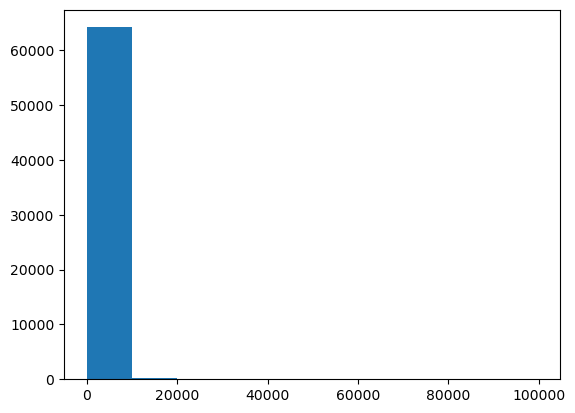

In [58]:
plt.hist(manga_data.scored_by[manga_data.scored_by < 1e5])
# plt.semilogx()
plt.show()

In [59]:
pd.qcut(anime_data.scored_by, 10).value_counts().sort_index()

scored_by
(-0.001, 10.0]          2724
(10.0, 31.0]            2302
(31.0, 75.0]            2486
(75.0, 146.6]           2482
(146.6, 307.0]          2508
(307.0, 782.0]          2490
(782.0, 2077.0]         2498
(2077.0, 6086.2]        2498
(6086.2, 28858.8]       2498
(28858.8, 2685033.0]    2499
Name: count, dtype: int64

In [60]:
anime_data[anime_data.scored_by == 0]

,anime_id,title,type,score,scored_by,status,episodes,start_date,end_date,source,...,producers,licensors,synopsis,background,main_picture,url,trailer_url,title_english,title_japanese,title_synonyms
16062,55701,Kimetsu no Yaiba: Hashira Geiko-hen,tv,NaN,0,not_yet_aired,NaN,NaN,NaN,manga,...,[],[],New season of Kimetsu no Yaiba.,NaN,https://cdn.myanimelist.net/images/anime/1230/...,https://myanimelist.net/anime/55701/Kimetsu_no...,https://www.youtube.com/watch?v=Sf4cKpeyAbo,Demon Slayer: Kimetsu no Yaiba Hashira Trainin...,鬼滅の刃 柱稽古編,[]
16065,54789,Boku no Hero Academia 7th Season,tv,NaN,0,not_yet_aired,NaN,NaN,NaN,manga,...,['Shueisha'],[],7th season of Boku no Hero Academia,NaN,https://cdn.myanimelist.net/images/anime/1954/...,https://myanimelist.net/anime/54789/Boku_no_He...,https://www.youtube.com/watch?v=DQp71pChp4s,My Hero Academia Season 7,僕のヒーローアカデミア,['My Hero Academia 7']
16071,55644,Dr. Stone: New World Part 2,tv,NaN,0,not_yet_aired,NaN,2023-10-01,NaN,manga,...,[],[],Part 2 of Dr. Stone: New World.,NaN,https://cdn.myanimelist.net/images/anime/1171/...,https://myanimelist.net/anime/55644/Dr_Stone__...,NaN,NaN,Dr.STONE NEW WORLD,['Dr. Stone 3rd Season Part 2']
16074,49303,Alice to Therese no Maboroshi Koujou,movie,NaN,0,not_yet_aired,1.0,2023-09-15,2023-09-15,original,...,[],[],"Masamune, a third-year middle school student, ...",NaN,https://cdn.myanimelist.net/images/anime/1429/...,https://myanimelist.net/anime/49303/Alice_to_T...,https://www.youtube.com/watch?v=CUenxyQYMjs,Maboroshi,アリスとテレスのまぼろし工場,"[""Alice and Therese's Illusion Factory"", 'The ..."
16075,54918,Tokyo Revengers: Tenjiku-hen,tv,NaN,0,not_yet_aired,NaN,2023-10-01,NaN,manga,...,[],[],Third season of Tokyo Revengers.,NaN,https://cdn.myanimelist.net/images/anime/1265/...,https://myanimelist.net/anime/54918/Tokyo_Reve...,https://www.youtube.com/watch?v=bMeWENMdq3k,NaN,東京リベンジャーズ 天竺編,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20603,50234,Cheng Li Laile Liao Yi Tiao Long,movie,NaN,0,not_yet_aired,NaN,NaN,NaN,picture_book,...,[],[],NaN,NaN,https://cdn.myanimelist.net/images/anime/1059/...,https://myanimelist.net/anime/50234/Cheng_Li_L...,https://www.youtube.com/watch?v=QSBS3BvZV6c,Dragon In Town,城里来了一条龙,[]
20774,55566,Wasted Chef,NaN,NaN,0,not_yet_aired,NaN,NaN,NaN,NaN,...,[],[],NaN,NaN,NaN,https://myanimelist.net/anime/55566/Wasted_Chef,NaN,NaN,NaN,[]
20874,55809,Xian Ni,ona,NaN,0,not_yet_aired,NaN,2023-01-01,NaN,novel,...,['Tencent Penguin Pictures'],[],NaN,NaN,https://cdn.myanimelist.net/images/anime/1542/...,https://myanimelist.net/anime/55809/Xian_Ni,NaN,NaN,仙逆,['Renegade Immortal']
21463,54989,Sylvanian Families Movie: Flair kara no Okurimono,movie,NaN,0,not_yet_aired,1.0,2023-11-23,2023-11-23,other,...,[],[],Movie for Sylvanian Families,NaN,https://cdn.myanimelist.net/images/anime/1616/...,https://myanimelist.net/anime/54989/Sylvanian_...,https://www.youtube.com/watch?v=UZPMyvx-CeM,NaN,劇場版 シルバニアファミリー フレアからのおくりもの,[]


In [61]:
pd.qcut(manga_data.scored_by, 10).value_counts().sort_index()

scored_by
(-0.001, 3.0]        8649
(3.0, 5.0]           4783
(5.0, 10.0]          6252
(10.0, 22.0]         6413
(22.0, 46.0]         6492
(46.0, 90.0]         6382
(90.0, 182.0]        6435
(182.0, 385.0]       6470
(385.0, 994.0]       6477
(994.0, 394362.0]    6480
Name: count, dtype: int64

In [62]:
anime_data_stable_rating = anime_data[anime_data.scored_by > 10]
manga_data_stable_rating = manga_data[manga_data.scored_by > 10]

In [63]:
len(anime_data_stable_rating), len(manga_data_stable_rating)


(22261, 45149)

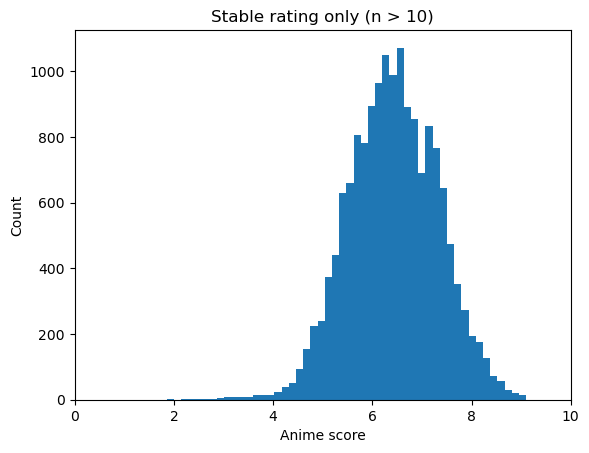

In [64]:
plt.hist(anime_data_stable_rating.score, bins = 50)

plt.xlabel("Anime score")
plt.ylabel("Count")

plt.title("Stable rating only (n > 10)")
plt.xlim(0, 10)
plt.show()

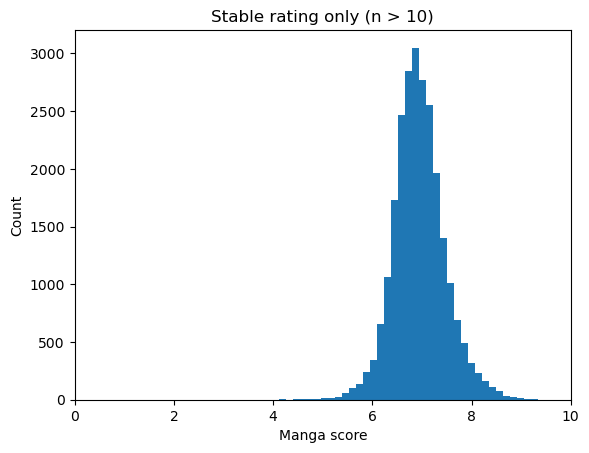

In [65]:
plt.hist(manga_data_stable_rating.score, bins = 50)

plt.xlabel("Manga score")
plt.ylabel("Count")

plt.title("Stable rating only (n > 10)")
plt.xlim(0, 10)
plt.show()

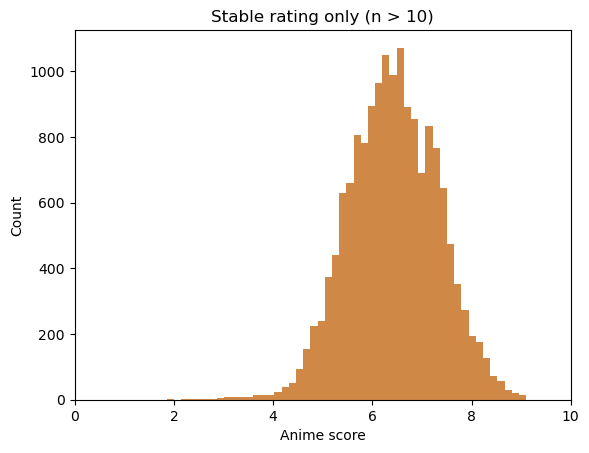

In [66]:
plt.hist(anime_data.score, bins = 50, alpha = 0.7)
plt.hist(anime_data_stable_rating.score, bins = 50, alpha = 0.7)

plt.xlabel("Anime score")
plt.ylabel("Count")

plt.title("Stable rating only (n > 10)")
plt.xlim(0, 10)
plt.show()

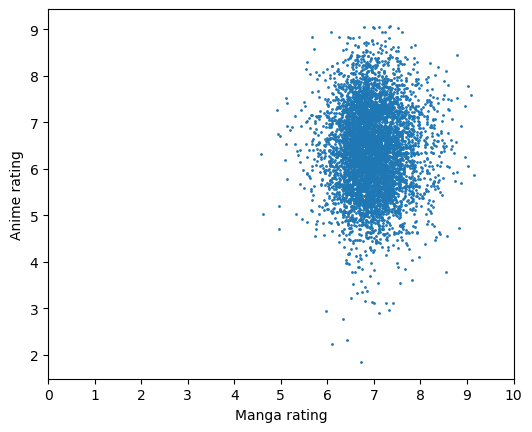

In [67]:
plt.scatter(manga_data.score.sample(len(anime_data), random_state = 454545), anime_data.score, s = 1)
plt.xticks(range(11))
plt.xticks(range(11))
plt.xlabel("Manga rating")
plt.ylabel("Anime rating")
plt.gca().set_aspect("equal")

In [72]:
same_titles = manga_data.merge(anime_data, on = "title", suffixes = ["_m", "_a"]).sort_values("title")

In [73]:
# for i, row in manga_data.iterrows():
#     synonyms = row.title_synonyms
    
#     for synonym in synonyms:
#         for j, row2 in manga_data.iterrows():
#             pass

#     if i >= 20:
#         break

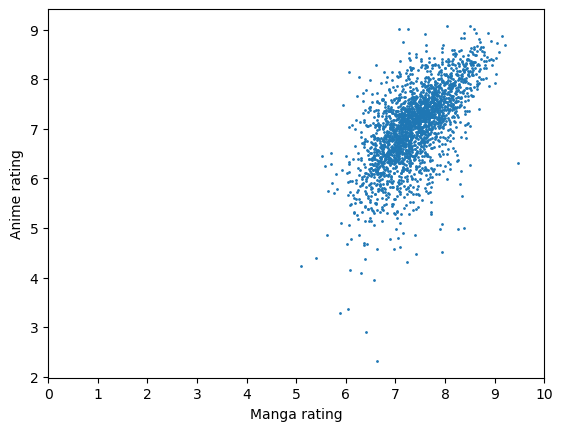

In [75]:
plt.scatter(same_titles.score_m, same_titles.score_a, s = 1)
plt.xticks(range(11))
plt.xticks(range(11))
plt.xlabel("Manga rating")
plt.ylabel("Anime rating")
plt.gca().set_aspect("equal")

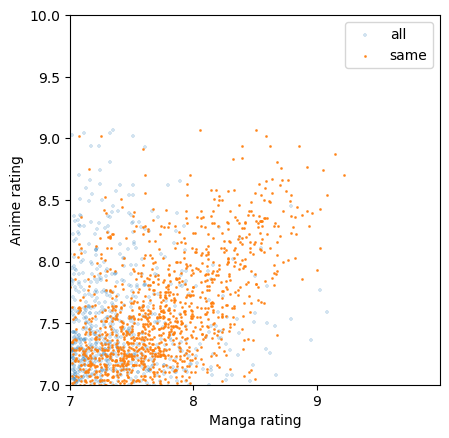

In [89]:
plt.scatter(manga_data.score.sample(len(anime_data), random_state = 454545), anime_data.score, s = 7,marker = "+", alpha = 0.2, label = "all")
plt.scatter(same_titles.score_m, same_titles.score_a, s = 1, alpha = 0.8, label = "same")

plt.xlim(7, 10)
plt.ylim(7, 10)

plt.xticks(range(7, 10))
plt.xticks(range(7, 10))
plt.legend()

plt.xlabel("Manga rating")
plt.ylabel("Anime rating")
plt.gca().set_aspect("equal")

In [87]:
same_titles[["score_m", "score_a"]].corr()

,score_m,score_a
score_m,1.000000,0.625913
score_a,0.625913,1.000000


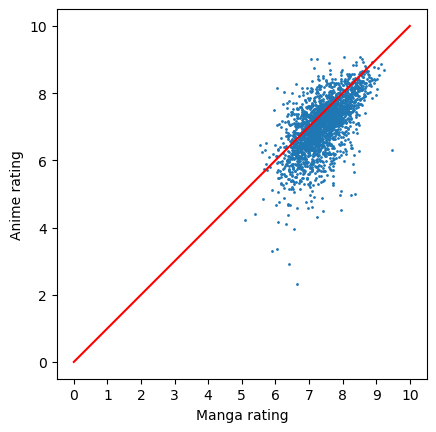

In [91]:
plt.scatter(same_titles.score_m, same_titles.score_a, s = 1)

plt.plot([0, 10], [0, 10], c = "r")

plt.xticks(range(11))
plt.xticks(range(11))
plt.xlabel("Manga rating")
plt.ylabel("Anime rating")
plt.gca().set_aspect("equal")

In [96]:
highly_rated = same_titles[same_titles.score_m >= 9][["title", "score_m", "score_a"]]
highly_rated["diff"] = np.abs(highly_rated.score_m - highly_rated.score_a)
highly_rated

,title,score_m,score_a,diff
0,Berserk,9.47,6.31,3.16
2,Fullmetal Alchemist,9.03,8.11,0.92
12,Grand Blue,9.03,8.43,0.60
13,Kingdom,9.00,7.93,1.07
6,Monster,9.15,8.87,0.28
1,One Piece,9.22,8.70,0.52
10,Slam Dunk,9.08,8.54,0.54
3,Vinland Saga,9.05,8.74,0.31


In [97]:
same_titles[same_titles.score_m < same_titles.score_a]

,manga_id,title,type_m,score_m,scored_by_m,status_m,volumes,chapters,start_date_m,end_date_m,...,producers,licensors,synopsis_a,background_a,main_picture_a,url_a,trailer_url,title_english_a,title_japanese_a,title_synonyms_a
20,126146,"""Oshi no Ko""",manga,8.68,58169,currently_publishing,NaN,NaN,2020-04-23,NaN,...,"['Shueisha', 'CyberAgent', 'Kadokawa']",['Sentai Filmworks'],"In the entertainment world, celebrities often ...",NaN,https://cdn.myanimelist.net/images/anime/1812/...,https://myanimelist.net/anime/52034/Oshi_no_Ko,https://www.youtube.com/watch?v=1yXa8MAmocQ,[Oshi No Ko],【推しの子】,['My Star']
2414,82899,15 Bishoujo Hyouryuuki,manga,6.75,171,finished,1.0,10.0,2012-06-21,2013-05-02,...,['HoriPro'],[],"After a heavy storm, Kazuma Shiraishi finds hi...",NaN,https://cdn.myanimelist.net/images/anime/13/31...,https://myanimelist.net/anime/5762/15_Bishoujo...,NaN,NaN,15美少女漂流記,['The Story of 15 Beautiful Girls Adrift']
2491,55783,30-sai no Hoken Taiiku,manga,6.36,239,finished,2.0,11.0,2010-10-27,2011-08-27,...,[],[],Based on Mitsuba and Ichijinsha's 30-sai no Ho...,NaN,https://cdn.myanimelist.net/images/anime/2/811...,https://myanimelist.net/anime/9624/30-sai_no_H...,https://www.youtube.com/watch?v=N1FSHkgVgt0,A Thirty-Year Old's Health and Physical Education,30歳の保健体育,['Sanjuu-sai no Hoken Taiiku']
954,112236,86,manga,7.59,1155,currently_publishing,NaN,NaN,2018-02-16,NaN,...,"['Aniplex', 'Kadokawa', 'Bandai Spirits']",[],"According to the Republic of San Magnolia, the...",NaN,https://cdn.myanimelist.net/images/anime/1987/...,https://myanimelist.net/anime/41457/86,https://www.youtube.com/watch?v=WVegRUOgkPM,86 Eighty-Six,86―エイティシックス―,['Eighty Six']
1087,53539,ACCA: 13-ku Kansatsu-ka,manga,7.51,893,finished,6.0,37.0,2013-06-25,2016-10-25,...,"['Bandai Visual', 'Square Enix', 'Lantis', 'Ni...",['Funimation'],ACCA—a national body of the kingdom of Dowa th...,NaN,https://cdn.myanimelist.net/images/anime/3/837...,https://myanimelist.net/anime/33337/ACCA__13-k...,https://www.youtube.com/watch?v=9KLcXHQZyls,ACCA: 13-Territory Inspection Dept.,ACCA 13区監察課,"['ACCA: 13th Territory Inspection Department',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,2987,Zetman,manga,6.31,1228,finished,1.0,4.0,1989-07-04,1994-12-27,...,"['TV Asahi', 'Asatsu DK', 'YTV', 'Toho', 'Saku...","['VIZ Media', 'NYAV Post']",The story starts off with a face-off between t...,NaN,https://cdn.myanimelist.net/images/anime/1955/...,https://myanimelist.net/anime/11837/Zetman,https://www.youtube.com/watch?v=2POvUa8qpq8,Zetman,ゼットマン,[]
364,15205,Zetsuen no Tempest,manga,7.90,6726,finished,10.0,50.0,2009-07-10,2013-10-12,...,"['Aniplex', 'Dentsu', 'Square Enix', 'Mainichi...",['Aniplex of America'],"Yoshino Takigawa, an ordinary teenager, is sec...",Zetsuen no Tempest draws heavily on two Shakes...,https://cdn.myanimelist.net/images/anime/7/424...,https://myanimelist.net/anime/14075/Zetsuen_no...,https://www.youtube.com/watch?v=xP78R0b70yE,Blast of Tempest,絶園のテンペスト,['Zetsuen no Tempest: The Civilization Blaster']
490,122392,Zom 100: Zombie ni Naru made ni Shitai 100 no ...,manga,7.61,9621,currently_publishing,NaN,NaN,2018-10-19,NaN,...,"['Shogakukan-Shueisha Productions', 'dugout']",['VIZ Media'],"In a trash-filled apartment, 24-year-old Akira...",The anime is part of a production deal between...,https://cdn.myanimelist.net/images/anime/1384/...,https://myanimelist.net/anime/54112/Zom_100__Z...,https://www.youtube.com/watch?v=GAMrUx-esS8,Zom 100: Bucket List of the Dead,ゾン100～ゾンビになるまでにしたい100のこと～,"['Bucket List of The Dead, Zombie 100: 100 Thi..."
2409,116028,Zombieland Saga,manga,6.79,160,currently_publishing,NaN,NaN,2018-10-08,NaN,...,"['Avex Pictures', 'Cygames', 'dugout']",['Funimation'],Sakura Minamoto dreams of becoming an idol. Un...,Zombieland Saga is an original anime productio...,https://cdn.myanimelist.net/images/anime/1084/...,https://myanimelist.net/anime/37976/Zombieland...,https://www.youtube.com/watch?v=O3VO4z

In [98]:
manga_data.real_start_date = pd.to_datetime(manga_data.real_start_date, format = "mixed")

In [107]:
date_parts = manga_data.start_date.str.split("-", expand = True)

In [110]:
# date_parts[(date_parts[0].isna() & date_parts[1].isna())]

,0,1,2
941,NaN,NaN,NaN
2147,NaN,NaN,NaN
2333,NaN,NaN,NaN
2471,NaN,NaN,NaN
2608,NaN,NaN,NaN
...,...,...,...
61395,NaN,NaN,NaN
61724,NaN,NaN,NaN
62006,NaN,NaN,NaN
62013,NaN,NaN,NaN


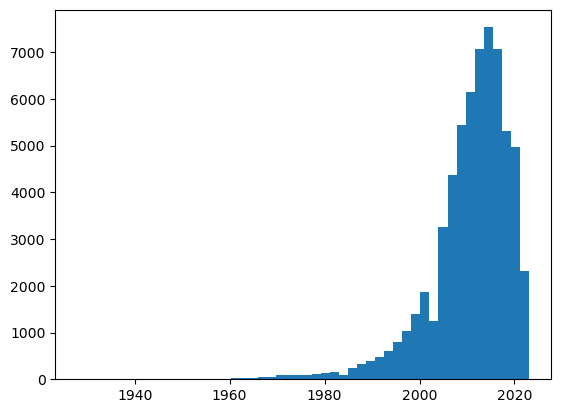

In [113]:
plt.hist(manga_data.real_start_date.dt.year, bins = 50)
plt.show()

In [114]:
manga_data[(manga_data.real_start_date.dt.year >= 2020) & (manga_data.real_start_date.dt.year < 2023)]

,manga_id,title,type,score,scored_by,status,volumes,chapters,start_date,end_date,...,demographics,authors,serializations,synopsis,background,main_picture,url,title_english,title_japanese,title_synonyms
26,145863,Sayonara Eri,manga,8.70,60899,finished,1.0,NaN,2022-04-11,2022-04-11,...,['Shounen'],"[{'id': 41158, 'first_name': 'Tatsuki', 'last_...",['Shounen Jump+'],"Suffering from a terminal illness, Yuuta's mot...",Sayonara Eri was published digitally as an Eng...,https://cdn.myanimelist.net/images/manga/3/263...,https://myanimelist.net/manga/145863/Sayonara_Eri,"Goodbye, Eri",さよなら絵梨,[]
30,126146,"""Oshi no Ko""",manga,8.68,58169,currently_publishing,NaN,NaN,2020-04-23,NaN,...,['Seinen'],"[{'id': 2139, 'first_name': 'Aka', 'last_name'...",['Young Jump'],Sixteen-year-old Ai Hoshino is a talented and ...,"""Oshi no Ko"" has been published digitally in E...",https://cdn.myanimelist.net/images/manga/3/233...,https://myanimelist.net/manga/126146/Oshi_no_Ko,[Oshi No Ko],【推しの子】,"['My Star', '【Oshi no Ko】']"
74,138673,Look Back,manga,8.38,52661,finished,1.0,NaN,2021-07-19,2021-07-19,...,['Shounen'],"[{'id': 41158, 'first_name': 'Tatsuki', 'last_...",['Shounen Jump+'],Fourth-grader Ayumu Fujino regularly draws fou...,Look Back was published digitally as an Englis...,https://cdn.myanimelist.net/images/manga/3/249...,https://myanimelist.net/manga/138673/Look_Back,Look Back,ルックバック,[]
77,126287,Sousou no Frieren,manga,8.61,23322,currently_publishing,NaN,NaN,2020-04-28,NaN,...,['Shounen'],"[{'id': 23829, 'first_name': 'Kanehito', 'last...",['Shounen Sunday'],"The demon king has been defeated, and the vict...",Sousou no Frieren has been published in Englis...,https://cdn.myanimelist.net/images/manga/3/232...,https://myanimelist.net/manga/126287/Sousou_no...,Frieren: Beyond Journey's End,葬送のフリーレン,['Frieren at the Funeral']
87,132214,Omniscient Reader,manhwa,8.40,38739,currently_publishing,NaN,NaN,2020-05-26,NaN,...,[],"[{'id': 53209, 'first_name': '', 'last_name': ...",['Naver Webtoon'],Kim Dokja does not consider himself the protag...,Omniscient Reader is an adaptation of sing N s...,https://cdn.myanimelist.net/images/manga/2/238...,https://myanimelist.net/manga/132214/Omniscien...,Omniscient Reader,전지적 독자 시점,"[""Omniscient Reader's Viewpoint"", 'Jeonji-jeok..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64821,155752,Spunk,manga,NaN,0,currently_publishing,NaN,NaN,2022-05-12,NaN,...,['Seinen'],"[{'id': 3035, 'first_name': 'Hideki', 'last_na...",['Comic Beam'],"Spunk follows Kana Kurita, a woman who has alw...",NaN,https://cdn.myanimelist.net/images/manga/2/283...,https://myanimelist.net/manga/155752/Spunk,NaN,SPUNK,[]
64825,157835,PSO2 New Genesis: Central!,manga,NaN,1,currently_publishing,NaN,NaN,2021-09-15,NaN,...,[],"[{'id': 66980, 'first_name': '', 'last_name': ...",[],Story following the exploits and updates in Ph...,PSO2 New Genesis: Central! is a series origina...,https://cdn.myanimelist.net/images/manga/2/285...,https://myanimelist.net/manga/157835/PSO2_New_...,Central!,PSO2 ニュージェネシス せんとらるっ!,[]
64830,160296,Happy Candy Virus,manga,NaN,0,finished,4.0,54.0,2021-08-02,2023-03-13,...,[],"[{'id': 67322, 'first_name': 'Kaori', 'last_na...",['Manga Park'],NaN,NaN,https://cdn.myanimelist.net/images/manga/3/286...,https://myanimelist.net/manga/160296/Happy_Can...,NaN,ハッピーキャンディーウイルス,[]
64831,160604,Suibu Yametai Hagino-san,one_shot,NaN,0,finished,NaN,1.0,2022-03-03,2022-03-03,...,['Shounen'],"[{'id': 67029, 'first_name': '', 'last_name': ...",['Shounen Champion (Weekly)'],NaN,NaN,https://cdn.myanimelist.net/images/manga/2/285...,https://myanimelist.net/manga/160604/Suibu_Yam...,NaN,吹部やめたい萩野さん,[]


In [118]:
recent = manga_data[(manga_data.real_start_date.dt.year >= 2020) & (manga_data.real_start_date.dt.year < 2023)]

In [139]:
old = manga_data[(manga_data.real_start_date.dt.year >= 2000) & (manga_data.real_start_date.dt.year < 2003)]

In [147]:
very_old = manga_data[(manga_data.real_start_date.dt.year >= 1980) & (manga_data.real_start_date.dt.year < 1983)]


In [153]:
len(recent), len(old), len(very_old)

(6706, 2631, 214)

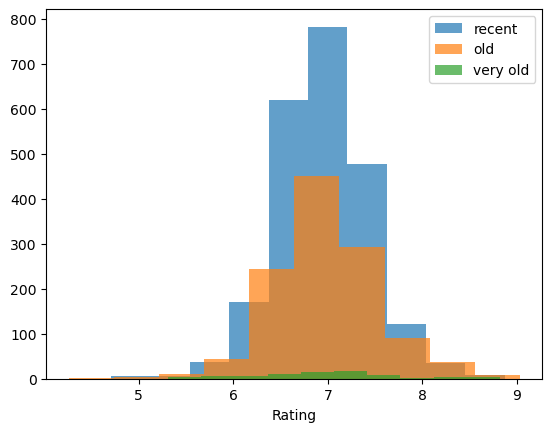

In [158]:
plt.hist(recent.score, label = "recent", alpha = 0.7)
plt.hist(old.score, label = "old", alpha = 0.7)
plt.hist(very_old.score, label = "very old", alpha = 0.7)

plt.legend()
plt.xlabel("Rating")
plt.show()

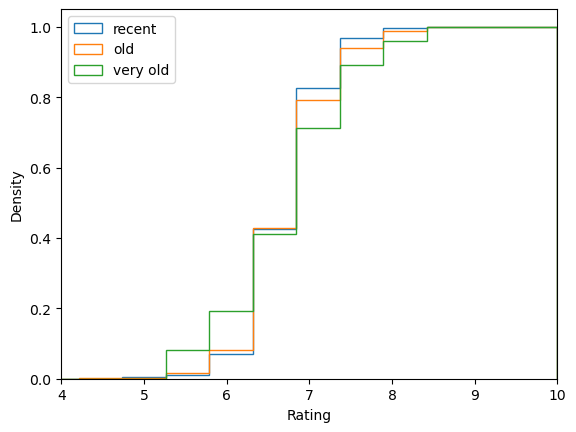

In [160]:
plt.hist(recent.score, label = "recent", density = True, cumulative = True, histtype = "step", bins = np.linspace(0,10,20))
plt.hist(old.score, label = "old", density = True, cumulative = True, histtype = "step", bins = np.linspace(0,10,20))
plt.hist(very_old.score, label = "very old", density = True, cumulative = True, histtype = "step", bins = np.linspace(0,10,20))

plt.xlim(4, 10)
plt.legend()
plt.xlabel("Rating")
plt.ylabel("Density")
plt.show()

In [156]:
from scipy.stats import ks_1samp

In [157]:
ks_1samp(recent.score, old.score)

KstestResult(statistic=np.float64(nan), pvalue=np.float64(nan), statistic_location=np.float64(nan), statistic_sign=np.float64(nan))